In [ ]:
import os
import glob
import time
import pickle
import gzip
import numpy as np
import pandas as pd
import seaborn as sns
from numba import njit
import concurrent.futures
from tqdm import tqdm
from scipy import signal
import scipy.optimize as opt
import scipy.special as spec
import warnings
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from pathlib import Path


Code + simulations

In [5]:
ROOT = Path.cwd()
Input = ROOT / "Input"
Output = ROOT / "Output"

In [6]:
D_FIXED = 1.0
k_FIXED = 1/100000
b0_FIXED = 0.3
dt = 0.01 
Ttot = 215000
L = 170 
steps = int(Ttot / dt)      



input_file_path = r"Input/input_par.csv" #imput file from the notebook folder

output_folder = Output


Langevin simulation

You can use the files in the output folder

In [ ]:
@njit(nogil=True, cache=True)
def evolve(steps, dt, b0, s, k, D, z, L):
    n = np.full(L, 10.0, dtype=np.float64)
    n_next = np.empty(L, dtype=np.float64)
    sqrt_dt = np.sqrt(dt)
    tau = int(25 * 4 / dt)  
    
    num_samples = (steps - tau) // tau
    if num_samples < 0: num_samples = 0
        
    sampln = np.zeros((num_samples, L), dtype=np.float64)
    sample_index = 0 
    
    for t in range(steps):
        for i in range(L):
            dw = np.random.normal(0.0, sqrt_dt)
            left = n[i-1] if i > 0 else n[L-1]
            right = n[i+1] if i < L-1 else n[0]
            laplaciann = left - 2.0 * n[i] + right
            
            dnt = b0 + (z - k * n[i]) * n[i] + D * laplaciann
            noise_coeff = s * n[i]
            milst = 0.5 * noise_coeff * s * (dw**2 - dt)
            
            n_next[i] = n[i] + dnt * dt + noise_coeff * dw + milst
            if n_next[i] < 1e-12: n_next[i] = 1e-12
                
        for i in range(L): n[i] = n_next[i]

        if t % tau == 0 and sample_index < num_samples and t > tau: 
            for i in range(L): sampln[sample_index, i] = n[i]
            sample_index += 1

    return sampln


def worker_simulation(task_data):
    idx, params_row, tot_rows = task_data
    lam_nom, corr_len, s_val, z_val = params_row[:4]
    
    sampln = evolve(steps, dt, b0_FIXED, s_val, k_FIXED, D_FIXED, z_val, L)
    
    real_params = [lam_nom, corr_len, s_val, z_val, b0_FIXED, k_FIXED, D_FIXED, L]
    
    return idx, {
        'params': real_params,
        'raw_data': np.float32(sampln)
    }

_ = evolve(100, dt, 0.3, 0.5, k_FIXED, D_FIXED, 0.01, L)

file_name = os.path.basename(input_file_path)
base_name = os.path.splitext(file_name)[0]
save_path = os.path.join(output_folder, f"results_{base_name}.pkl.gz") #cambiato

df = pd.read_csv(input_file_path, header=None)
param_table = df.values.tolist()
        
valid_rows = [row for row in param_table if len(row) >= 4]
tot_rows = len(valid_rows)
tasks = [(idx, row, tot_rows) for idx, row in enumerate(valid_rows)]
results_list = [None] * tot_rows 
    
with concurrent.futures.ThreadPoolExecutor(max_workers=3) as executor:
 
    for idx, result_dict in tqdm(executor.map(worker_simulation, tasks), total=tot_rows, desc="Progress"):
        results_list[idx] = result_dict
            
with gzip.open(save_path, 'wb') as f:
    pickle.dump(results_list, f, protocol=pickle.HIGHEST_PROTOCOL)

Progress:   0%|          | 0/400 [00:00<?, ?it/s]


TypingError: Failed in nopython mode pipeline (step: nopython frontend)
[1m[1mNo implementation of function Function(<built-in function sub>) found for signature:
 
 >>> sub(unicode_type, float64)
 
There are 14 candidate implementations:
[1m      - Of which 10 did not match due to:
      Overload of function 'sub': File: <numerous>: Line N/A.
        With argument(s): '(unicode_type, float64)':[0m
[1m       No match.[0m
[1m      - Of which 2 did not match due to:
      Operator Overload in function 'sub': File: unknown: Line unknown.
        With argument(s): '(unicode_type, float64)':[0m
[1m       No match for registered cases:
        * (int64, int64) -> int64
        * (int64, uint64) -> int64
        * (uint64, int64) -> int64
        * (uint64, uint64) -> uint64
        * (float32, float32) -> float32
        * (float64, float64) -> float64
        * (complex64, complex64) -> complex64
        * (complex128, complex128) -> complex128[0m
[1m      - Of which 2 did not ma

Analysis of PDF and spatial correlations (it requires a bit)

Analyzing and Fitting: 100%|██████████| 168/168 [03:20<00:00,  1.19s/it]


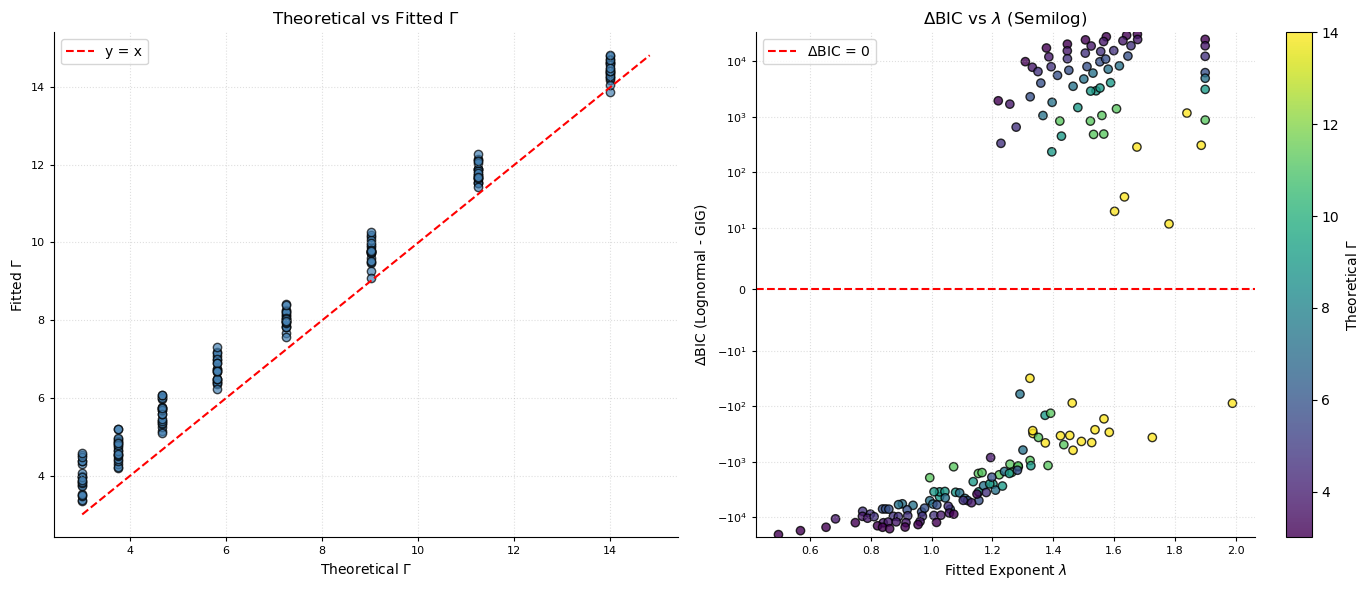

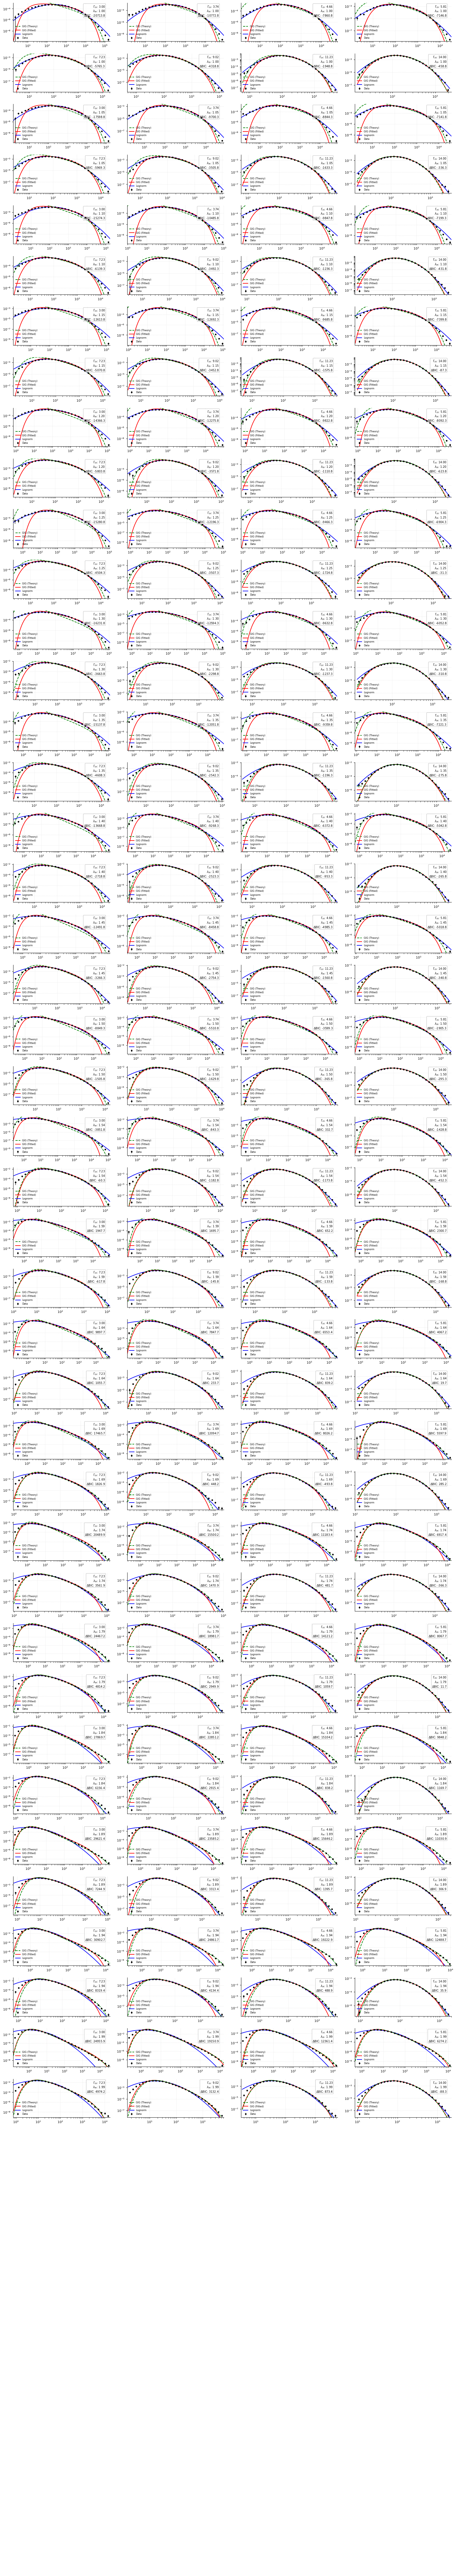

In [9]:
warnings.filterwarnings("ignore", category=RuntimeWarning)

@njit
def fast_acf_space(data, max_lag):
    T, L = data.shape
    mu = 0.0
    for t in range(T):
        for i in range(L):
            mu += data[t, i]
    mu /= (T * L)
    
    var = 0.0
    for t in range(T):
        for i in range(L):
            var += (data[t, i] - mu)**2
    var /= (T * L)

    acf = np.zeros(max_lag)
    acf[0] = 1.0
    if var <= 0: return acf

    for r in range(1, max_lag):
        cov = 0.0
        for t in range(T):
            for i in range(L):
                right = (i + r) % L
                cov += (data[t, i] - mu) * (data[t, right] - mu)
        acf[r] = (cov / (T * L)) / var
    return acf

def exp_decay(x, length_scale):
    return np.exp(-x / length_scale)

def logSAD(n, b, c, mu):
    n = np.maximum(n, 1e-12)
    kv_val = spec.kv(1 - 2*mu, 2*np.sqrt(b/c))
    if kv_val <= 0 or not np.isfinite(kv_val): 
        return -np.inf * np.ones_like(n)
    return ((0.5 - mu)*np.log(b*c) - b/n - n/c - (2.0 - 2.0*mu)*np.log(n) - np.log(2) - np.log(kv_val))

def loglik_GIG(params, vecN):
    return -np.sum(logSAD(vecN, params[0], params[1], params[2]))

def fit_GIG(vecN, p0_guess):
    res = opt.minimize(loglik_GIG, p0_guess, args=(vecN,),
                       bounds=[(p0_guess[0]/10,p0_guess[0]*10), (p0_guess[1]/10,p0_guess[1]*10), (p0_guess[2]/10,p0_guess[2]*10)],
                       method="Nelder-Mead",
                       options={'maxiter':100000})
    return (res.x, res.fun) if res.success else (None, np.inf)

def loglik_Lognorm(params, vecN):
    mu, sigma = params
    n = np.maximum(vecN, 1e-12)
    log_pdf = -np.log(n * sigma * np.sqrt(2 * np.pi)) - ((np.log(n) - mu)**2) / (2 * sigma**2)
    return -np.sum(log_pdf)

def fit_Lognorm(vecN):
    log_data = np.log(vecN)
    p0 = [np.mean(log_data), np.std(log_data) + 1e-3]
    res = opt.minimize(loglik_Lognorm, p0, args=(vecN,),
                       bounds=[(None, None), (1e-5, None)],
                       method="Nelder-Mead")
    return (res.x, res.fun) if res.success else (None, np.inf)

def get_pdf_GIG(x, params):
    b, c, mu = params
    return np.exp(logSAD(x, b, c, mu))

def get_pdf_Lognorm(x, params):
    mu, sigma = params
    return (1 / (x * sigma * np.sqrt(2 * np.pi))) * np.exp(-((np.log(x) - mu)**2) / (2 * sigma**2))

def analyze_simulation(result_dict):
    if result_dict is None:
        return None
        
    params = result_dict['params']
    lam_nom, corr_len, s_val, z_val, b0, k_val, D_val, L = params
    
    c_val = 1.0 / k_val if k_val > 0 else 1e6
    
    raw_data = result_dict['raw_data']
    all_positive = raw_data[raw_data > 1e-6].flatten()
    
    if len(all_positive) < 50:
        return None  
        
    max_lag_s = int(min(15, L/2))
    acf_space = fast_acf_space(raw_data, max_lag_s)
    r_values = np.arange(max_lag_s)
    
    try:
        valid_fit_s = acf_space > 0
        popt_s, _ = opt.curve_fit(exp_decay, r_values[valid_fit_s], acf_space[valid_fit_s], p0=[1.0])
        xi_fit = popt_s[0]
    except Exception:
        xi_fit = np.nan

    gamma_theoretical = corr_len
    lambda_theoretical =  lam_nom
    
    p0_gig = []
    popt_gig, nll_gig = None, np.inf
    
    if not np.isnan(gamma_theoretical):
        s_eff = s_val / np.sqrt(2.0 * gamma_theoretical)
        b0_gig = (2.0 * b0) / (s_eff**2)
        c_gig = (s_eff**2) / (2.0 * (1.0 / c_val))
        mu_gig = z_val / (s_eff**2)
        p0_gig = [b0_gig, c_gig, mu_gig]
        
        popt_gig, nll_gig = fit_GIG(all_positive, p0_gig)
        
    popt_log, nll_log = fit_Lognorm(all_positive)
    
    delta_bic = np.nan
    lambda_fit = np.nan
    
    if popt_gig is not None and popt_log is not None:
        n_obs = len(all_positive)
        bic_gig = 3 * np.log(n_obs) + 2 * nll_gig
        bic_log = 2 * np.log(n_obs) + 2 * nll_log
        delta_bic = bic_log - bic_gig 
        lambda_fit = 2.0 * (1.0 - popt_gig[2])

    min_val, max_val = all_positive.min(), all_positive.max()
    log_bins = np.logspace(np.log10(min_val), np.log10(max_val), 30)
    counts, edges = np.histogram(all_positive, bins=log_bins)
    
    bin_centers = np.sqrt(edges[:-1] * edges[1:])
    bin_widths = edges[1:] - edges[:-1]
    
    valid_bins = counts > 0
    density = counts[valid_bins] / (bin_widths[valid_bins] * len(all_positive))
    density_err = np.sqrt(counts[valid_bins]) / (bin_widths[valid_bins] * len(all_positive))
    
    return {
        'gamma_theoretical': gamma_theoretical,
        'gamma_fit': xi_fit,
        's_theoretical': s_val,
        'lambda_theoretical': lambda_theoretical,
        'n_samples': len(all_positive),
        'p0_gig': p0_gig,
        'popt_gig': popt_gig.tolist() if popt_gig is not None else [],
        'popt_lognorm': popt_log.tolist() if popt_log is not None else [],
        'delta_bic': delta_bic,
        'lambda_fit': lambda_fit,
        'bin_centers': bin_centers[valid_bins].tolist(),
        'density': density.tolist(),
        'density_err': density_err.tolist(),
        'min_data': min_val,
        'max_data': max_val
    }

def set_style(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', which='both', length=3, labelsize=8)
    ax.grid(True, linestyle=':', alpha=0.4)

if __name__ == '__main__':
    input_sim_file = r"Output\results_params.pkl.gz"
    output_analysis_file = r"Output\results_params.pkl"
    
    with gzip.open(input_sim_file, 'rb') as f:
        results_list = pickle.load(f)
        
    valid_results = [r for r in results_list if r is not None]
   
    
    analyzed_data = Parallel(n_jobs=-1)(
        delayed(analyze_simulation)(res) for res in tqdm(valid_results, desc="Analyzing and Fitting")
    )
    
    final_results = [r for r in analyzed_data if r is not None]
    df = pd.DataFrame(final_results)
    
    df_save = df.drop(columns=['bin_centers', 'density', 'density_err'])
    df_save.to_pickle(output_analysis_file)
    df_save.to_csv(output_analysis_file.replace('.pkl', '.csv'), index=False)


    fig_main = plt.figure(figsize=(14, 6))

    ax1 = fig_main.add_subplot(1, 2, 1)
    mask_gamma = df['gamma_theoretical'].notna() & df['gamma_fit'].notna()
    ax1.scatter(df.loc[mask_gamma, 'gamma_theoretical'], df.loc[mask_gamma, 'gamma_fit'], alpha=0.7, edgecolor='k', color='steelblue')
    
    if mask_gamma.any():
        min_val = min(df.loc[mask_gamma, 'gamma_theoretical'].min(), df.loc[mask_gamma, 'gamma_fit'].min())
        max_val = max(df.loc[mask_gamma, 'gamma_theoretical'].max(), df.loc[mask_gamma, 'gamma_fit'].max())
        ax1.plot([min_val, max_val], [min_val, max_val], 'r--', label='y = x')
        
    ax1.set_xlabel(r'Theoretical $\Gamma$')
    ax1.set_ylabel(r'Fitted $\Gamma$')
    ax1.set_title(r'Theoretical vs Fitted $\Gamma$')
    ax1.legend()
    set_style(ax1)

    ax2 = fig_main.add_subplot(1, 2, 2)
    mask_bic = df['lambda_fit'].notna() & df['delta_bic'].notna()
    
    sc = ax2.scatter(df.loc[mask_bic, 'lambda_fit'], df.loc[mask_bic, 'delta_bic'], 
                     c=df.loc[mask_bic, 'gamma_theoretical'], cmap='viridis', 
                     alpha=0.8, edgecolor='k')
    
    cbar = fig_main.colorbar(sc, ax=ax2)
    cbar.set_label(r'Theoretical $\Gamma$')
    
    ax2.axhline(0, color='r', linestyle='--', label=r'$\Delta$BIC = 0')
    ax2.set_yscale('symlog', linthresh=10.0)
    ax2.set_xlabel(r'Fitted Exponent $\lambda$')
    ax2.set_ylabel(r'$\Delta$BIC (Lognormal - GIG)')
    ax2.set_title(r'$\Delta$BIC vs $\lambda$ (Semilog)')
    ax2.legend()
    set_style(ax2)

    fig_main.tight_layout()
    plt.show()

    n_rows, n_cols = 51, 4
    fig_grid, axes_grid = plt.subplots(n_rows, n_cols, figsize=(16, 90))
    axes_flat = axes_grid.flatten()
    def safe_float(val):
        if pd.isna(val):
            return np.nan
        val_str = str(val).strip()
        if '/' in val_str:
            num, den = val_str.split('/')
            return float(num) / float(den)
        return float(val)
    
    n_plots = min(len(df), n_rows * n_cols)
    
    for i in range(len(axes_flat)):
        ax = axes_flat[i]
        
        if i < n_plots:
            row = df.iloc[i]
            x_data = np.array(row['bin_centers'])
            y_data = np.array(row['density'])
            y_err = np.array(row['density_err'])
            
            ax.errorbar(x_data, y_data, yerr=y_err, fmt='o', color='k', 
                        markersize=3, elinewidth=1, capsize=0, zorder=3, label='Data')
            
            x_lims = (x_data.min() * 0.8, x_data.max() * 1.2)
            valid_y = y_data[y_data > 0]
            if len(valid_y) > 0:
                y_lims = (valid_y.min() * 0.5, y_data.max() * 2.0)
            else:
                y_lims = ax.get_ylim()
            
            x_plot = np.logspace(np.log10(row['min_data']), np.log10(row['max_data']), 100)
            
            if len(row['p0_gig']) > 0:
                y_gig_theo = get_pdf_GIG(x_plot, row['p0_gig'])
                ax.plot(x_plot, y_gig_theo, 'g--', lw=1.5, zorder=2.5, label='GIG (Theory)')

            if len(row['popt_gig']) > 0:
                y_gig = get_pdf_GIG(x_plot, row['popt_gig'])
                ax.plot(x_plot, y_gig, 'r-', lw=1.5, zorder=2, label='GIG (Fitted)')
                
            if len(row['popt_lognorm']) > 0:
                y_log = get_pdf_Lognorm(x_plot, row['popt_lognorm'])
                ax.plot(x_plot, y_log, 'b-', lw=1.5, zorder=1, label='Lognorm')
                
            ax.set_xscale('log')
            ax.set_yscale('log')
            
            ax.set_xlim(x_lims)
            ax.set_ylim(y_lims)
            
            info_text = (f"$\\Gamma_{{th}}$: {safe_float(row['gamma_theoretical']):.2f}\n"
                         f"$\\lambda_{{th}}$: {safe_float(row['lambda_theoretical']):.2f}\n"
                         f"$\\Delta$BIC: {safe_float(row['delta_bic']):.1f}")
            ax.annotate(info_text, xy=(0.95, 0.95), xycoords='axes fraction', 
                        ha='right', va='top', fontsize=7,
                        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", alpha=0.8, lw=0.5))
            
            ax.legend(loc='lower left', fontsize=6, frameon=False)
            
        else:
            ax.axis('off')
            
        set_style(ax)

    fig_grid.tight_layout(pad=1.0)
    plt.show()

Scatter plot of the paramaters: theory vs simulation

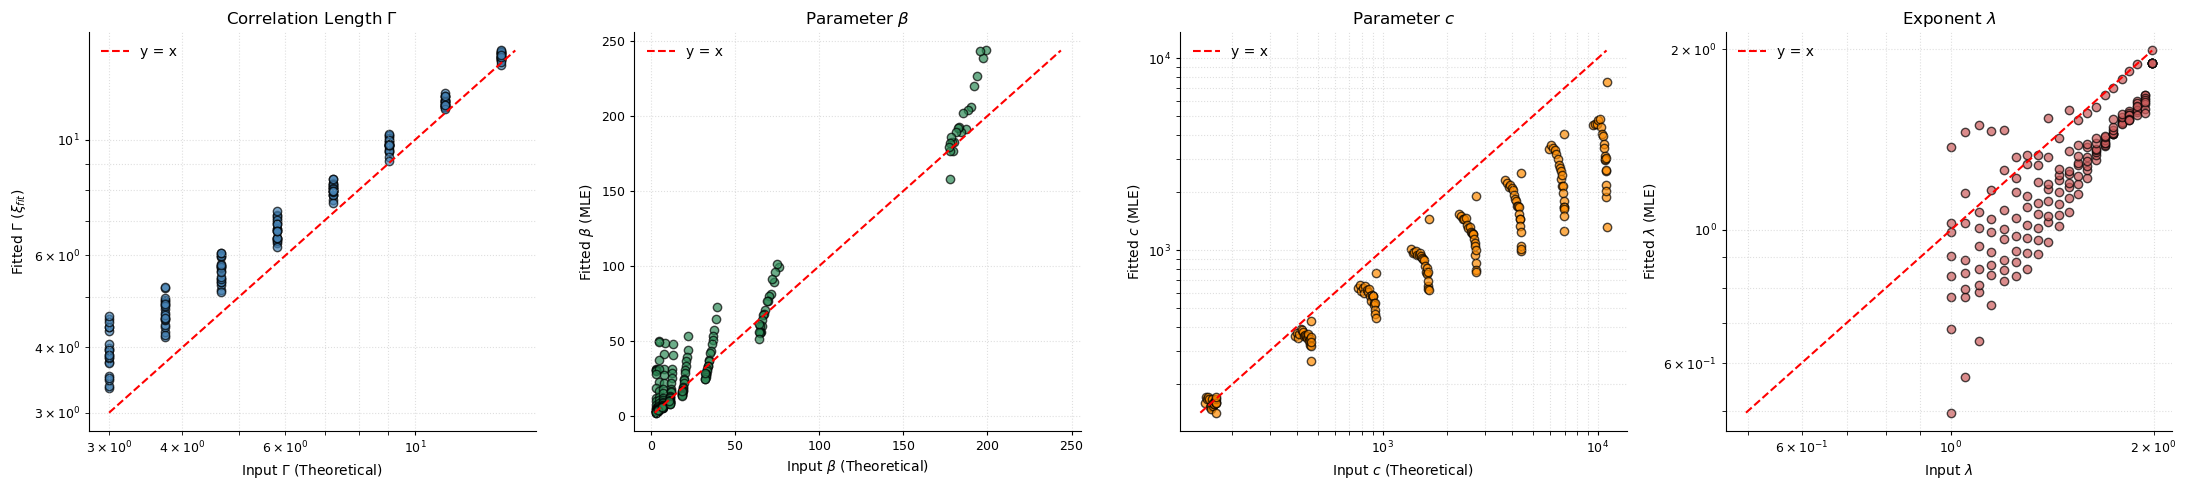

In [10]:
df_results = pd.read_pickle(output_analysis_file)

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

def set_style(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', which='both', length=3, labelsize=9)
    ax.grid(True, which='both', linestyle=':', alpha=0.4)

fitted_b = []
fitted_c = []
fitted_lambda = []

for p in df_results['popt_gig']:
    if isinstance(p, (list, np.ndarray)) and len(p) == 3:
        fitted_b.append(p[0])
        fitted_c.append(p[1])
        fitted_lambda.append(2.0 * (1.0 - p[2]))
    else:
        fitted_b.append(np.nan)
        fitted_c.append(np.nan)
        fitted_lambda.append(np.nan)

df_results['beta_fit'] = fitted_b
df_results['c_fit'] = fitted_c
df_results['lambda_fit_param'] = fitted_lambda

ax1 = axes[0]
mask_g = df_results['gamma_theoretical'].notna() & df_results['gamma_fit'].notna() & (df_results['gamma_theoretical'] > 0) & (df_results['gamma_fit'] > 0)
ax1.scatter(df_results.loc[mask_g, 'gamma_theoretical'], df_results.loc[mask_g, 'gamma_fit'], 
            alpha=0.7, edgecolor='k', color='steelblue')
if mask_g.any():
    min_v = min(df_results.loc[mask_g, 'gamma_theoretical'].min(), df_results.loc[mask_g, 'gamma_fit'].min())
    max_v = max(df_results.loc[mask_g, 'gamma_theoretical'].max(), df_results.loc[mask_g, 'gamma_fit'].max())
    ax1.plot([min_v, max_v], [min_v, max_v], 'r--', label='y = x')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel(r'Input $\Gamma$ (Theoretical)')
ax1.set_ylabel(r'Fitted $\Gamma$ ($\xi_{fit}$)')
ax1.set_title(r'Correlation Length $\Gamma$')
ax1.legend(frameon=False)
set_style(ax1)

ax2 = axes[1]
beta_theo_list = []
c_theo_list = []
for idx, row in df_results.iterrows():
    b0_val = 0.3 
    k_fixed = 1/100000
    c_val = 1.0 / k_fixed
    gamma_th = row['gamma_theoretical']
    s_val = row['s_theoretical']
    
    if not np.isnan(gamma_th) and gamma_th > 0:
        s_eff = s_val / np.sqrt(2.0 * gamma_th)
        beta_theo_list.append((2.0 * b0_val) / (s_eff**2))
        c_theo_list.append((s_eff**2) / (2.0 * (1.0 / c_val)))
    else:
        beta_theo_list.append(np.nan)
        c_theo_list.append(np.nan)

df_results['beta_theoretical'] = beta_theo_list
df_results['c_theoretical'] = c_theo_list

mask_b = df_results['beta_theoretical'].notna() & df_results['beta_fit'].notna() & (df_results['beta_theoretical'] > 0) & (df_results['beta_fit'] > 0)
ax2.scatter(df_results.loc[mask_b, 'beta_theoretical'], df_results.loc[mask_b, 'beta_fit'], 
            alpha=0.7, edgecolor='k', color='seagreen')
if mask_b.any():
    min_v = min(df_results.loc[mask_b, 'beta_theoretical'].min(), df_results.loc[mask_b, 'beta_fit'].min())
    max_v = max(df_results.loc[mask_b, 'beta_theoretical'].max(), df_results.loc[mask_b, 'beta_fit'].max())
    ax2.plot([min_v, max_v], [min_v, max_v], 'r--', label='y = x')

ax2.set_xlabel(r'Input $\beta$ (Theoretical)')
ax2.set_ylabel(r'Fitted $\beta$ (MLE)')
ax2.set_title(r'Parameter $\beta$')
ax2.legend(frameon=False)
set_style(ax2)

ax3 = axes[2]
mask_c = df_results['c_theoretical'].notna() & df_results['c_fit'].notna() & (df_results['c_theoretical'] > 0) & (df_results['c_fit'] > 0)
ax3.scatter(df_results.loc[mask_c, 'c_theoretical'], df_results.loc[mask_c, 'c_fit'], 
            alpha=0.7, edgecolor='k', color='darkorange')
if mask_c.any():
    min_v = min(df_results.loc[mask_c, 'c_theoretical'].min(), df_results.loc[mask_c, 'c_fit'].min())
    max_v = max(df_results.loc[mask_c, 'c_theoretical'].max(), df_results.loc[mask_c, 'c_fit'].max())
    ax3.plot([min_v, max_v], [min_v, max_v], 'r--', label='y = x')
ax3.set_xscale('log')
ax3.set_yscale('log')
ax3.set_xlabel(r'Input $c$ (Theoretical)')
ax3.set_ylabel(r'Fitted $c$ (MLE)')
ax3.set_title(r'Parameter $c$')
ax3.legend(frameon=False)
set_style(ax3)

ax4 = axes[3]
mask_l = df_results['lambda_theoretical'].notna() & df_results['lambda_fit_param'].notna() & (df_results['lambda_theoretical'] > 0) & (df_results['lambda_fit_param'] > 0)
ax4.scatter(df_results.loc[mask_l, 'lambda_theoretical'], df_results.loc[mask_l, 'lambda_fit_param'], 
            alpha=0.7, edgecolor='k', color='indianred')
if mask_l.any():
    min_v = min(df_results.loc[mask_l, 'lambda_theoretical'].min(), df_results.loc[mask_l, 'lambda_fit_param'].min())
    max_v = max(df_results.loc[mask_l, 'lambda_theoretical'].max(), df_results.loc[mask_l, 'lambda_fit_param'].max())
    ax4.plot([min_v, max_v], [min_v, max_v], 'r--', label='y = x')
ax4.set_xscale('log')
ax4.set_yscale('log')
ax4.set_xlabel(r'Input $\lambda$')
ax4.set_ylabel(r'Fitted $\lambda$ (MLE)')
ax4.set_title(r'Exponent $\lambda$')
ax4.legend(frameon=False)
set_style(ax4)

plt.tight_layout()
plt.show()

Plots for the Methods section and SM

Parameters: [1.495, 11.234548886729174, 0.4474298610737942, 0.0022497055742704]


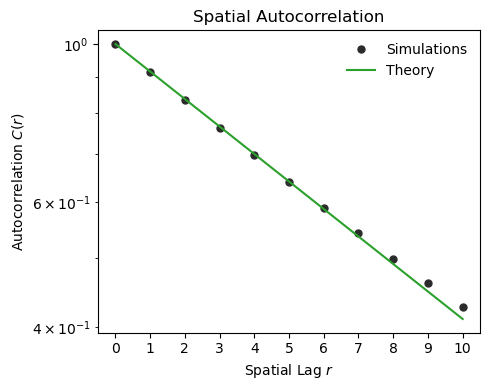

In [11]:

color_data = '#2b2b2b'
color_spat = '#2ca02c'


# params list: lam_nom, corr_len, s_val, z_val
target_params = [1.495, 11.2345, 0.44743, 0.00224971]

with gzip.open(input_sim_file, 'rb') as f:
    results_list = pickle.load(f)

matched_sim = None
for res in results_list:
    if res is not None:
        p = res['params'][:4]
        if np.all(np.isclose(p, target_params, atol=1e-5)):
            matched_sim = res
            break

if matched_sim is None:
    print("Simulation not found. Check the parameter values.")
else:
    print(f"Parameters: {matched_sim['params'][:4]}")
    
    raw_data = matched_sim['raw_data']
    gamma_th = matched_sim['params'][1]
    
    max_lag = 11
    acf = fast_acf_space(raw_data, max_lag)
    lags = np.arange(max_lag)
    acf_theo = np.exp(-lags / gamma_th)
    
    
    fig, ax = plt.subplots(figsize=(5, 4))
    
    ax.plot(lags, acf, 'o', color=color_data, markersize=5, label='Simulations')
    ax.plot(lags, acf_theo, '-', color=color_spat, lw=1.5, label='Theory')
    
    ax.set_yscale('log')
    ax.set_xlabel('Spatial Lag $r$')
    ax.set_ylabel('Autocorrelation $C(r)$')
    ax.set_title('Spatial Autocorrelation')
    ax.set_xticks(lags)
    
    ax.legend(frameon=False)
    
    plt.tight_layout()
    plt.show()

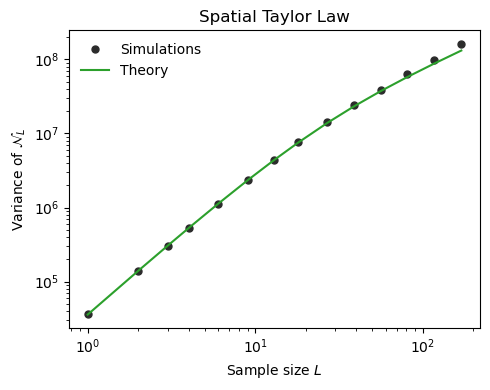

In [ ]:
color_data = '#2b2b2b'
color_spat = '#2ca02c'

def psi_scaling(x):
    return 1.0 - np.exp(-x) * np.sinh(x) / x

def taylor_analytic(S, Gamma, var_n):
    x = S / (2.0 * Gamma)
    return ((2 * Gamma)**2) * var_n * x * psi_scaling(x)

output_taylor_file = Output/"taylor_coordinates.csv"

L_sites = raw_data.shape[1]
var_n = np.var(raw_data, ddof=0)

sizes = np.unique(np.logspace(0, np.log10(L_sites), num=15, dtype=int))
taylor_emp = []
sizes_valid = []
taylor_th = []

for s in sizes:
    if s > L_sites: 
        continue
    b_sum = []
    for k in range(L_sites - s + 1):
        block = raw_data[:, k:k+s]
        b_sum.append(np.var(np.sum(block, axis=1), ddof=0))
        
    taylor_emp.append(np.mean(b_sum))
    sizes_valid.append(s)
    taylor_th.append(taylor_analytic(s, gamma_th, var_n))

sizes_valid = np.array(sizes_valid)
taylor_emp = np.array(taylor_emp)
taylor_th = np.array(taylor_th)



fig, ax = plt.subplots(figsize=(5, 4))

ax.plot(sizes_valid, taylor_emp, 'o', color=color_data, markersize=5, label='Simulations')
ax.plot(sizes_valid, taylor_th, '-', color=color_spat, lw=1.5, label='Theory')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Sample size $L$')
ax.set_ylabel(r'Variance of $n_L$')
ax.set_title('Spatial Taylor Law')
ax.legend(frameon=False)

plt.tight_layout()
plt.show()